# Personal Injury Accidents vs Population


In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt

from urban_mobility import fetch_data as fd
from urban_mobility import plotting as pl

fd.fetch_traffic_data()

Already have 2016.csv, skipping...
Already have 2017.csv, skipping...
Already have 2018.csv, skipping...
Already have 2019.csv, skipping...
Already have 2020.csv, skipping...
Already have 2021.csv, skipping...
Already have 2022.csv, skipping...
Already have 2023.csv, skipping...
Already have 2024.csv, skipping...
Already have 2025.csv, skipping...


In [2]:
YEARS = fd.DATA_YEARS

## Data Cleaning


Aggregate the accidents per district and year and join each district's population of that year (`fd.get_district_aggregate`, cached under `output/artifacts`). Then average each measure, and the population, over the years a district has data: states join the data set in different years (e.g. Nordrhein-Westfalen from 2019), so a plain sum over all years would understate the districts of late states.

In [3]:
agg_methods = {
    "inj_light": "sum",
    "inj_serious": "sum",
    "inj_fatal": "sum",
    "IstFuss": "sum",
    "IstRad": "sum",
    "IstKrad": "sum",
    "IstGkfz": "sum",
}
df_district_year = fd.get_district_aggregate(YEARS, agg_methods)
df_merged = (
    df_district_year.groupby("district")
    .agg({**{col: "mean" for col in pl.MEASURE_LABELS}, "population": "mean"})
    .reset_index()
)

### Plotting vs Population


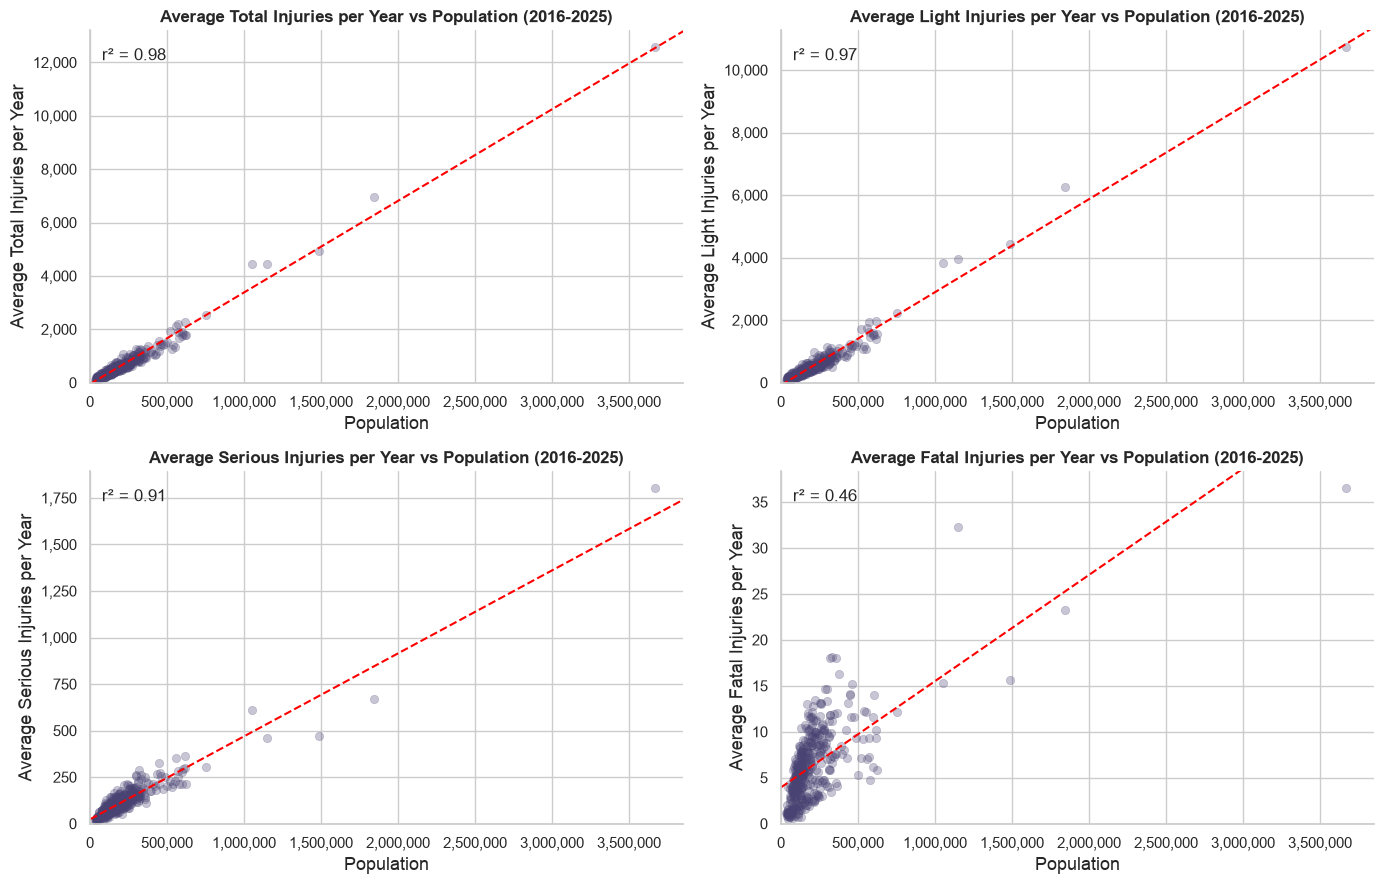

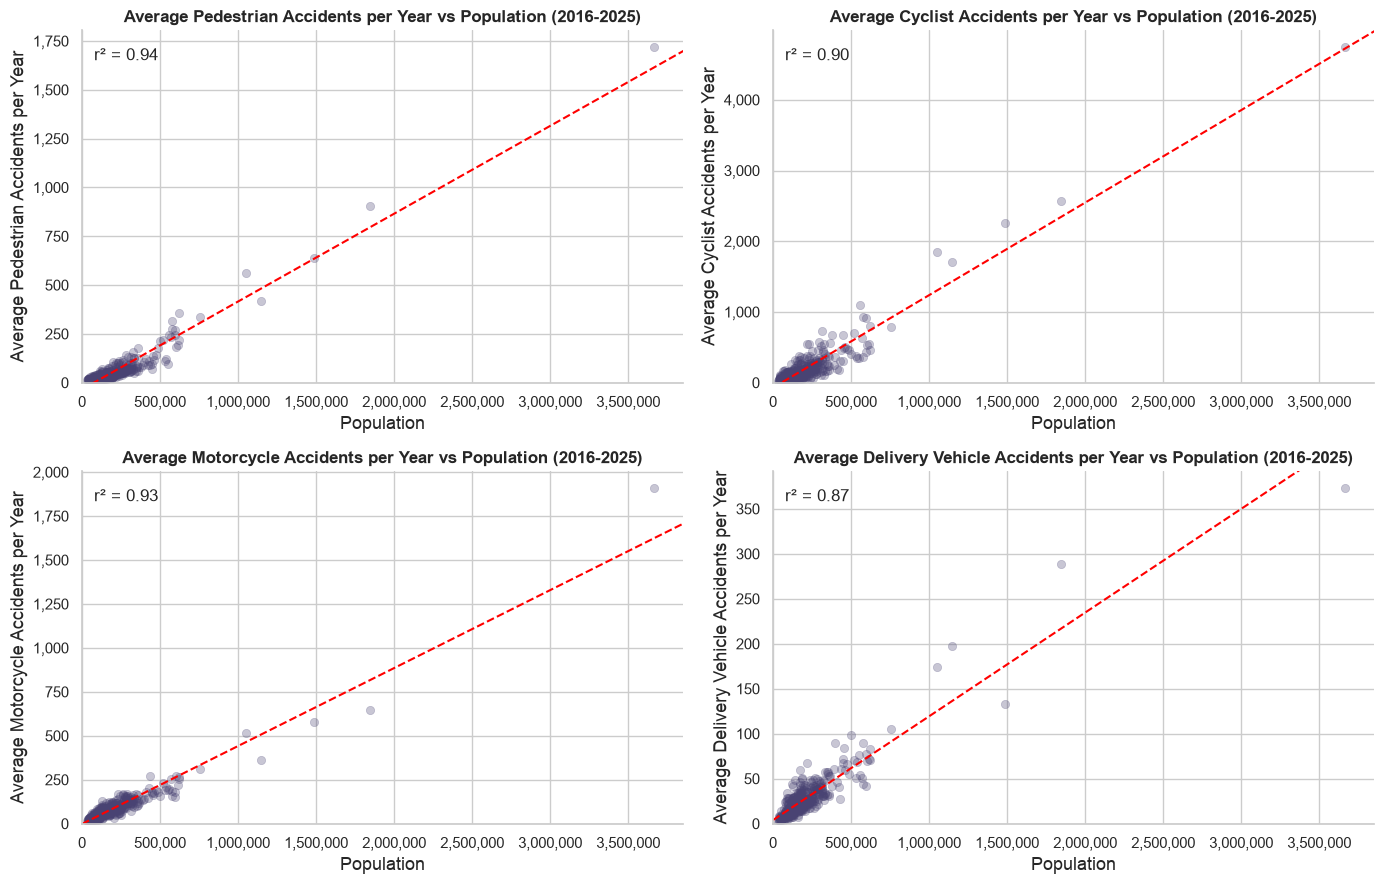

In [4]:
for group, measures in pl.MEASURE_GROUPS.items():
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for ax, (col, title) in zip(axes.flat, measures):
        pl.scatter_fit(
            df_merged, "population", col,
            f"Average {title} per Year vs Population ({YEARS[0]}-{YEARS[-1]})",
            "Population", f"Average {title} per Year", ax=ax,
        )
        ax.title.set_fontsize(12)
    fig.tight_layout()
    pl.save(fig, f"acc_per_pop_{group}")
    plt.show()